## 1. Préparation de l'environnement
## Nous importons les outils nécessaires pour le calcul et la visualisation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

## 2. Chargement et Standardisation
L'ACP est sensible aux échelles. Il est crucial de centrer et réduire les données pour que chaque variable ait une moyenne de 0 et une variance de 1.

In [8]:
# Chargement des données
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# Standardisation (Centrage-Réduction)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

3. Application de l'ACP
Nous projetons les données sur les deux premières composantes principales (PC1 et PC2).

In [9]:
# Création de l'objet PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Pourcentage de variance expliquée
explained_variance = pca.explained_variance_ratio_
print(f"Variance expliquée par PC1: {explained_variance[0]*100:.2f}%")
print(f"Variance expliquée par PC2: {explained_variance[1]*100:.2f}%")

Variance expliquée par PC1: 72.96%
Variance expliquée par PC2: 22.85%


4. Visualisation des résultats
Une bonne représentation comprend deux graphiques clés : le nuage des individus et le cercle des corrélations.

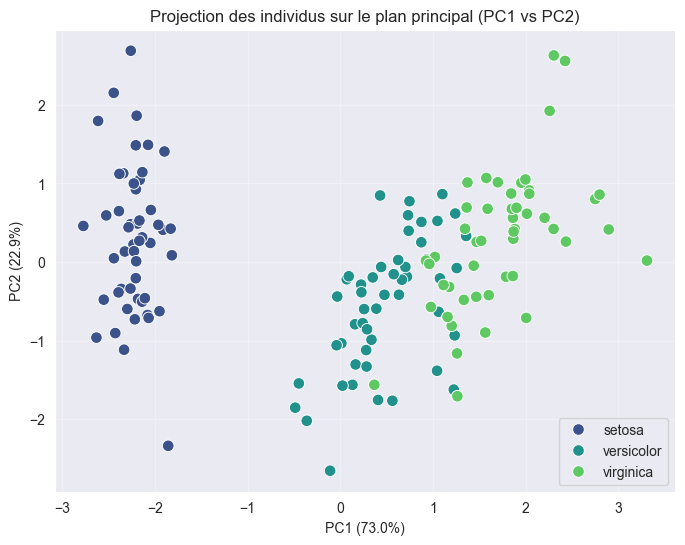

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=iris.target_names[y], palette='viridis', s=70)
plt.title('Projection des individus sur le plan principal (PC1 vs PC2)')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.grid(alpha=0.3)
plt.show()

B. Cercle des corrélations

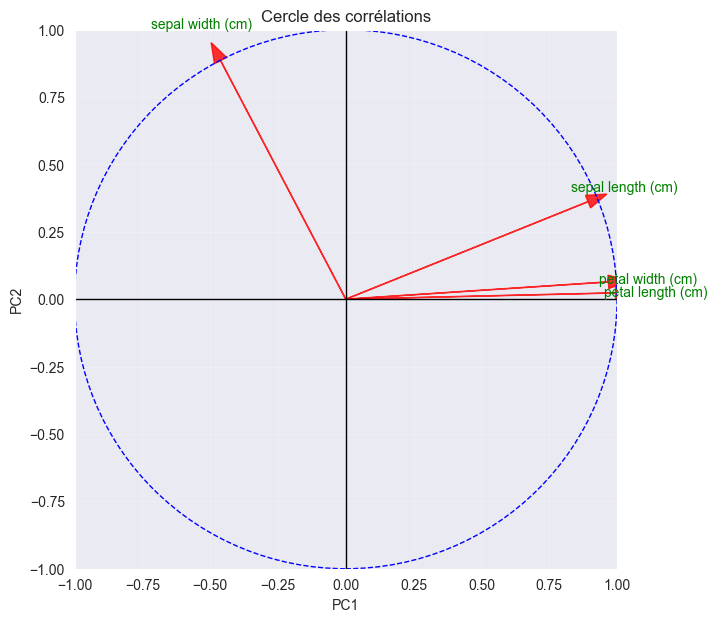

In [11]:
# Calcul des coordonnées des variables
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(7, 7))
plt.xlim(-1, 1)
plt.ylim(-1, 1)

# Tracé des vecteurs
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='r', alpha=0.8, head_width=0.05)
    plt.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, feature, color='g', ha='center', va='center')

# Tracé du cercle
circle = plt.Circle((0,0), 1, color='blue', fill=False, linestyle='--')
plt.gca().add_artist(circle)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.title('Cercle des corrélations')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.2)
plt.show()

L'interprétation d'une ACP (Analyse en Composantes Principales) se fait généralement en deux temps : l'analyse des variables (le cercle) et l'analyse des individus (le nuage de points).Voici comment structurer une interprétation complète et professionnelle :1. Qualité globale : L'éboulis des valeurs propresAvant d'interpréter les graphiques, on regarde quel pourcentage de l'information totale (la variance) est capturé par les deux premiers axes ($PC1$ et $PC2$).Si $PC1 + PC2 > 70\%$ : L'interprétation est très fiable.Si le score est faible : Il faut être prudent, car une grande partie de l'information reste "cachée" sur les axes suivants ($PC3$, $PC4$).2. Analyse des Variables (Cercle des corrélations)C'est ici que l'on donne du sens aux axes.Le sens des flèches : Si les variables "Prix" et "Qualité" sont du même côté de l'axe horizontal ($PC1$), cela signifie que $PC1$ représente le "Haut de gamme".L'opposition : Si "Vitesse" est à droite et "Consommation" est à gauche, l'axe montre un compromis : plus on va vite, moins on est économe.Le cercle unité : Une flèche qui touche presque le bord du cercle est une variable "maîtresse" de votre analyse. Une flèche courte est une variable "parasite" sur ce plan.3. Analyse des Individus (Le Nuage de points)Une fois que vous avez nommé vos axes grâce au cercle, vous pouvez interpréter la position des points (vos données réelles).Proximité : Deux points proches l'un de l'autre sont des individus qui se ressemblent (ils ont des caractéristiques similaires).Position sur les axes : * Un individu situé tout à droite sur un axe "Richesse" est un individu très riche.Un individu au centre du graphique est un individu "moyen" par rapport à l'ensemble du jeu de données.Groupements (Clusters) : Si vous voyez des amas de points se former, cela signifie qu'il existe des catégories naturelles dans vos données (ex: un groupe de clients "économes" vs un groupe "dépensiers").4. Exemple de rédaction typePour votre TP, vous pouvez utiliser ce modèle de phrase :"L'axe PC1 explique X% de la variance. Il est fortement corrélé positivement aux variables A et B, et négativement à la variable C. Nous pouvons donc interpréter cet axe comme étant l'indicateur de [Nom de votre concept]. On remarque que l'individu n°42 se situe à l'extrême droite de cet axe, ce qui signifie qu'il possède des valeurs très élevées pour A et B."Astuce pour le TP : N'oubliez pas de vérifier les individus atypiques (outliers). Un point très éloigné de tous les autres peut fausser toute l'ACP. Il est parfois utile de refaire l'analyse en le retirant pour voir si les axes changent.Avez-vous un jeu de données spé

In [14]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Chargement du dataset "Wine"
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# 2. Affichage des dimensions
print(f"Nombre de lignes (individus) : {df.shape[0]}")
print(f"Nombre de colonnes (variables) : {df.shape[1]}")

# 3. Préparation pour l'ACP
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 4. Exécution de l'ACP
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\n--- Aperçu des 5 premières lignes du dataset ---")
print(df.head())

Nombre de lignes (individus) : 178
Nombre de colonnes (variables) : 13

--- Aperçu des 5 premières lignes du dataset ---
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69        

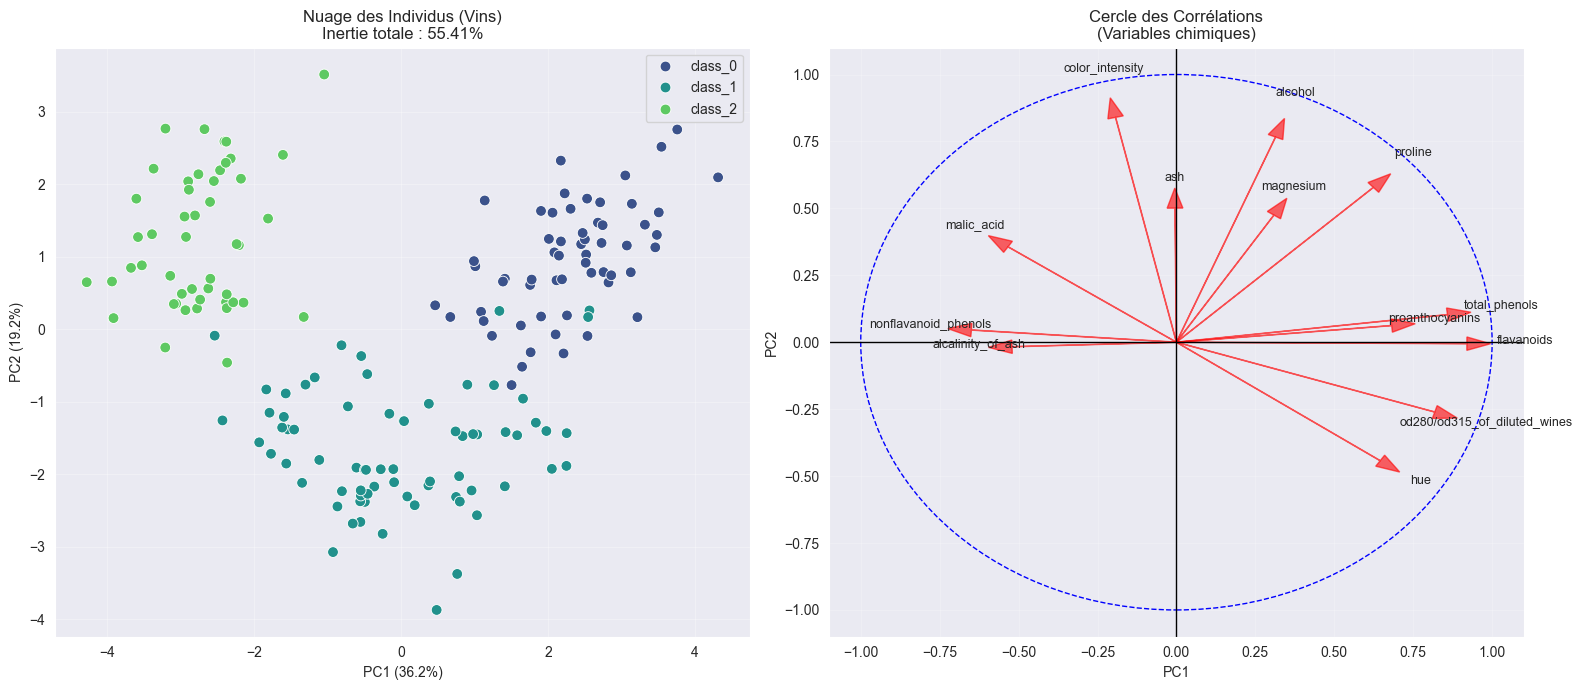

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- ÉTAPE 1 : Chargement et Préparation ---
data = load_wine()
X = data.data
y = data.target
features = data.feature_names

# Standardisation (Indispensable car les unités diffèrent : Alcool %, Magnésium mg, etc.)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- ÉTAPE 2 : Calcul de l'ACP ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
variance = pca.explained_variance_ratio_ * 100

# --- ÉTAPE 3 : Visualisation ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# A. Nuage des individus
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=[data.target_names[i] for i in y],
                palette='viridis', s=60, ax=ax1)
ax1.set_title(f'Nuage des Individus (Vins)\nInertie totale : {variance[0]+variance[1]:.2f}%')
ax1.set_xlabel(f'PC1 ({variance[0]:.1f}%)')
ax1.set_ylabel(f'PC2 ({variance[1]:.1f}%)')
ax1.grid(alpha=0.3)

# B. Cercle des corrélations
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
for i, feature in enumerate(features):
    ax2.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='red', alpha=0.6, head_width=0.05)
    ax2.text(loadings[i, 0]*1.2, loadings[i, 1]*1.2, feature, fontsize=9, ha='center')

circle = plt.Circle((0,0), 1, color='blue', fill=False, linestyle='--')
ax2.add_artist(circle)
ax2.set_xlim(-1.1, 1.1)
ax2.set_ylim(-1.1, 1.1)
ax2.axhline(0, color='black', lw=1)
ax2.axvline(0, color='black', lw=1)
ax2.set_title('Cercle des Corrélations\n(Variables chimiques)')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Dimensions : 178 lignes x 13 colonnes

--- VECTEUR DES MOYENNES ---
alcohol                          13.000618
malic_acid                        2.336348
ash                               2.366517
alcalinity_of_ash                19.494944
magnesium                        99.741573
total_phenols                     2.295112
flavanoids                        2.029270
nonflavanoid_phenols              0.361854
proanthocyanins                   1.590899
color_intensity                   5.058090
hue                               0.957449
od280/od315_of_diluted_wines      2.611685
proline                         746.893258
dtype: float64 



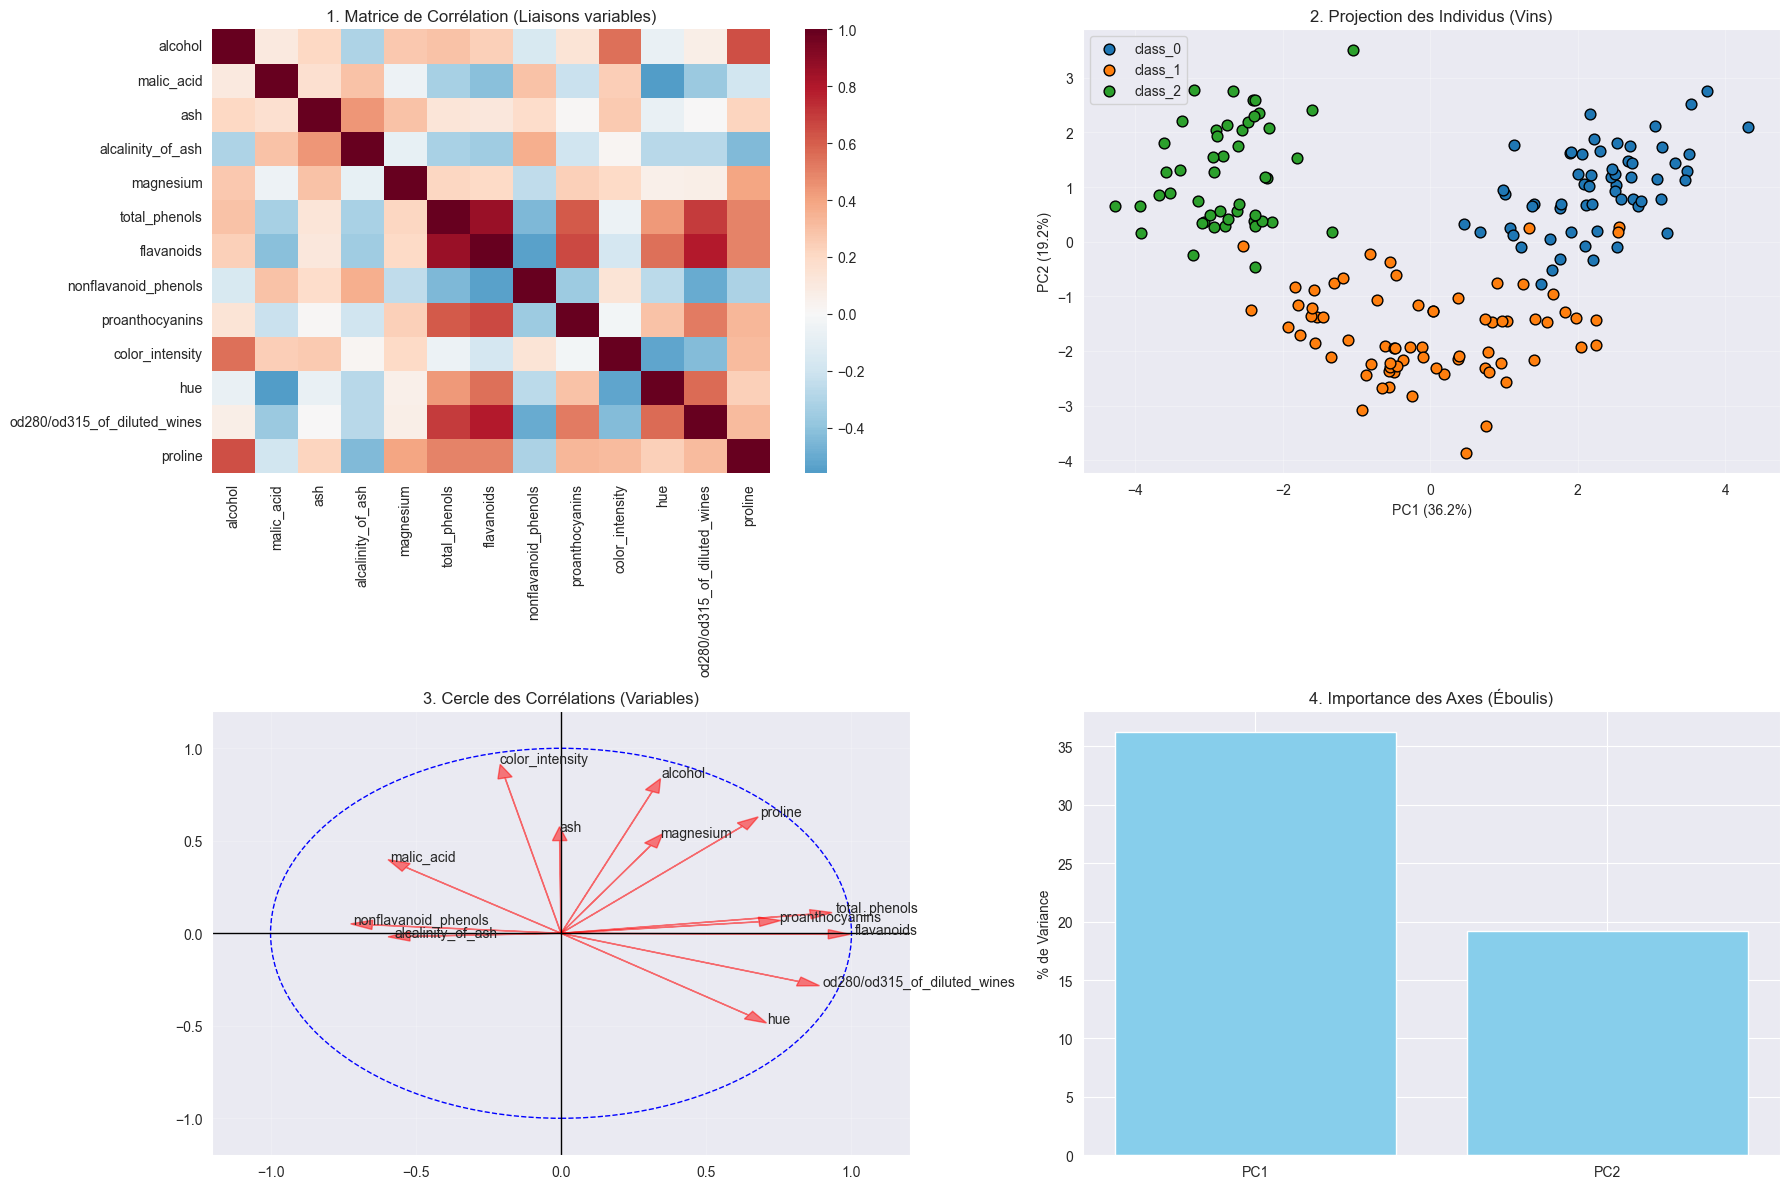

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. PRÉPARATION DES DONNÉES (Dataset Wine)
# ==========================================
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
target = wine.target
target_names = wine.target_names

print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes\n")

# ==========================================
# 2. STATISTIQUES (Moyennes & Corrélation)
# ==========================================
# Calcul des moyennes
moyennes = df.mean()
print("--- VECTEUR DES MOYENNES ---")
print(moyennes, "\n")

# Calcul de la matrice de corrélation
corr_matrix = df.corr()

# ==========================================
# 3. RÉALISATION DE L'ACP
# ==========================================
# Standardisation (Centrage-Réduction)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Application de l'ACP (2 composantes)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Variance expliquée
variance_ratio = pca.explained_variance_ratio_ * 100

# ==========================================
# 4. VISUALISATION COMPLÈTE
# ==========================================
plt.figure(figsize=(18, 12))

# --- Graphique 1 : Heatmap de Corrélation ---
plt.subplot(2, 2, 1)
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title("1. Matrice de Corrélation (Liaisons variables)")

# --- Graphique 2 : Nuage des Individus ---
plt.subplot(2, 2, 2)
colors = ['#440154', '#21918c', '#fde725']
for i, name in enumerate(target_names):
    plt.scatter(X_pca[target == i, 0], X_pca[target == i, 1],
                label=name, edgecolors='k', s=60)
plt.xlabel(f"PC1 ({variance_ratio[0]:.1f}%)")
plt.ylabel(f"PC2 ({variance_ratio[1]:.1f}%)")
plt.legend()
plt.title("2. Projection des Individus (Vins)")
plt.grid(alpha=0.3)

# --- Graphique 3 : Cercle des Corrélations ---
plt.subplot(2, 2, 3)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
for i, feature in enumerate(wine.feature_names):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='red', alpha=0.5, head_width=0.05)
    plt.text(loadings[i, 0]*1.1, loadings[i, 1]*1.1, feature, fontsize=10)

circle = plt.Circle((0,0), 1, color='blue', fill=False, linestyle='--')
plt.gca().add_artist(circle)
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("3. Cercle des Corrélations (Variables)")
plt.grid(alpha=0.2)

# --- Graphique 4 : Éboulis des valeurs propres ---
plt.subplot(2, 2, 4)
plt.bar(range(1, 3), variance_ratio, color='skyblue')
plt.xticks([1, 2], ['PC1', 'PC2'])
plt.ylabel('% de Variance')
plt.title("4. Importance des Axes (Éboulis)")

plt.tight_layout()
plt.show()

1. Les Individus : De quoi parle-t-on ?Dans ce jeu de données (le dataset Wine), les individus sont des échantillons de vins.Nombre : 178 individus.Origine : Ce sont des vins issus de trois cultivars (variétés de vignes) différents cultivés dans la même région en Italie.Leur rôle dans l'ACP : Sur votre graphique (le nuage de points), chaque point est un vin. L'ACP permet de voir si ces vins se ressemblent.Si deux points sont proches, cela signifie que leurs compositions chimiques sont quasi identiques.L'objectif est de voir si les vins d'un même groupe (ex: "class_0") se regroupent ensemble, prouvant que leur signature chimique est unique.2. Les Variables : Qu'est-ce qu'on mesure ?Les variables sont les caractéristiques chimiques mesurées pour chaque bouteille. Il y en a 13 au total. Voici les plus importantes pour votre interprétation :VariableCe qu'elle représenteAlcoholLe taux d'alcool (puissance du vin).Malic AcidL'acidité (donne de la fraîcheur ou de la verdeur).Total PhenolsLes composés antioxydants (structure et santé).FlavanoidsUn type de polyphénols (influence le goût et la couleur).Color IntensityLa force de la couleur (visuel).ProlineUn acide aminé (souvent lié à la maturité du raisin).3. Le lien entre les deux (La synthèse)L'ACP sert de "traducteur" entre ces deux mondes :Le Cercle des Corrélations vous dit comment les Variables sont liées entre elles (ex: "Les vins forts en alcool ont-ils aussi une couleur intense ?").Le Nuage des Individus vous dit comment les Vins se comportent par rapport à ces variables.En résumé :L'ACP prend ces 13 mesures chimiques (trop complexes à lire d'un coup) et crée deux nouveaux axes ($PC1$ et $PC2$).L'axe 1 (Horizontal) sépare souvent les vins selon leur "richesse" (phénols, flavonoïdes, proline).L'axe 2 (Vertical) peut séparer les vins selon leur "intensité" ou leur "acidité".C'est comme si vous preniez une photo d'un objet en 3D (vos 13 variables) sous l'angle le plus révélateur pour le voir en 2D sur votre écran.